## Projeto do Bootcamp Avanti - Machine Learning

🔹 Projeto 03

📌 Assunto: Classificação de lesões em folhas de feijão

🔗 Dataset: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification


### Participantes:
Cristiane Santos da Cunha

Eric Gabriel Aguiar de Alencar

Fabrício Almeida Santos

Ian Silva Nogueira

Jaime Teixeira de Araújo Júnior

Juliana Gonçalves Câmara

### ATIVIDADE-04-ETAPA-01
#### Objetivo: Apresentar informações do dataset





#### Baixar dataset do Kaggle

In [131]:
!pip install opendatasets
!pip install pandas
!pip install imagehash

In [132]:
import opendatasets as od
import pandas as pd

dataset_path = od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")

from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("KAGGLE_API_KEY")

Skipping, found downloaded files in "./bean-leaf-lesions-classification" (use force=True to force download)


In [133]:
# IMPORTAÇÕES

import pandas as pd
import os
import cv2
import imagehash
import matplotlib.pyplot as plt
%matplotlib inline
import random
import shutil


In [ ]:
!ls

bean-leaf-lesions-classification  drive  sample_data


### Criar um Dataframe com os metadados das imagens

In [ ]:
root_dir = './bean-leaf-lesions-classification'

#### Separação das imagens para treinamento, teste e validação


In [ ]:
# estrutura do data set

print(os.listdir("./bean-leaf-lesions-classification"))

['train', 'val.csv', 'test', 'classname.txt', 'train.csv', 'val']


In [134]:
train_dir = "./bean-leaf-lesions-classification/train"
test_dir = "./bean-leaf-lesions-classification/test"

NUM_TESTE = 154

# -------------------------------------------------------------------
# 1. Devolve todas as imagens de TESTE para TREINAMENTO
# -------------------------------------------------------------------

for classe in os.listdir(test_dir):

    pasta_test = os.path.join(test_dir, classe)
    pasta_train = os.path.join(train_dir, classe)

    if not os.path.isdir(pasta_test):
        continue

    os.makedirs(pasta_train, exist_ok=True)

    for imagem in os.listdir(pasta_test):

        origem = os.path.join(pasta_test, imagem)
        destino = os.path.join(pasta_train, imagem)

        shutil.move(origem, destino)

# -------------------------------------------------------------------
# 2. Lista todas as imagens do treinamento
# -------------------------------------------------------------------

todas_imagens = []

for classe in os.listdir(train_dir):

    pasta_train = os.path.join(train_dir, classe)

    if not os.path.isdir(pasta_train):
        continue

    for imagem in os.listdir(pasta_train):

        todas_imagens.append((classe, imagem))

# -------------------------------------------------------------------
# 3. Sorteia 154 imagens
# -------------------------------------------------------------------

imagens_teste = random.sample(todas_imagens, NUM_TESTE)

# -------------------------------------------------------------------
# 4. Move somente as 154 imagens sorteadas para TESTE
# -------------------------------------------------------------------

for classe, imagem in imagens_teste:

    origem = os.path.join(train_dir, classe, imagem)

    pasta_test = os.path.join(test_dir, classe)
    os.makedirs(pasta_test, exist_ok=True)

    destino = os.path.join(pasta_test, imagem)

    shutil.move(origem, destino)

print(f"{NUM_TESTE} imagens movidas para TESTE com sucesso.")

154 imagens movidas para TESTE com sucesso.


In [135]:
train_df = pd.read_csv("./bean-leaf-lesions-classification/train.csv")

train_df.head()

,image:FILE,category
0,train/healthy/healthy_train.98.jpg,0
1,train/healthy/healthy_train.148.jpg,0
2,train/healthy/healthy_train.306.jpg,0
3,train/healthy/healthy_train.305.jpg,0
4,train/healthy/healthy_train.40.jpg,0


In [136]:
print(train_df.columns)

Index(['image:FILE', 'category'], dtype='object')


In [137]:
# Validação

val_df = pd.read_csv("./bean-leaf-lesions-classification/val.csv")

imagens_csv = set(val_df["image:FILE"])
imagens_pasta = set()

val_dir = "./bean-leaf-lesions-classification/val"

for classe in os.listdir(val_dir):
    pasta = os.path.join(val_dir, classe)

    if os.path.isdir(pasta):
        for img in os.listdir(pasta):
            imagens_pasta.add(img)

faltando = imagens_csv - imagens_pasta
extras = imagens_pasta - imagens_csv

print(f"Imagens listadas no CSV: {len(imagens_csv)}")
print(f"Imagens encontradas na pasta: {len(imagens_pasta)}")
print(f"Imagens no CSV e ausentes na pasta: {len(faltando)}")
print(f"Imagens na pasta e ausentes no CSV: {len(extras)}")

Imagens listadas no CSV: 133
Imagens encontradas na pasta: 133
Imagens no CSV e ausentes na pasta: 133
Imagens na pasta e ausentes no CSV: 133


In [138]:
# Ler o CSV
train_df = pd.read_csv("./bean-leaf-lesions-classification/train.csv")

# Imagens listadas no CSV
imagens_csv = set(train_df["image:FILE"])

# Imagens existentes na pasta
imagens_pasta = set()

train_dir = "./bean-leaf-lesions-classification/train"

for classe in os.listdir(train_dir):
    pasta = os.path.join(train_dir, classe)

    if os.path.isdir(pasta):
        for img in os.listdir(pasta):
            imagens_pasta.add(img)

# Comparação
faltando = imagens_csv - imagens_pasta
extras = imagens_pasta - imagens_csv

print(f"Imagens listadas no CSV: {len(imagens_csv)}")
print(f"Imagens encontradas na pasta: {len(imagens_pasta)}")
print(f"Imagens no CSV e ausentes na pasta: {len(faltando)}")
print(f"Imagens na pasta e ausentes no CSV: {len(extras)}")

Imagens listadas no CSV: 1034
Imagens encontradas na pasta: 880
Imagens no CSV e ausentes na pasta: 1034
Imagens na pasta e ausentes no CSV: 880


In [139]:
# Teste

# Pasta de teste
test_dir = "./bean-leaf-lesions-classification/test"

# Conjunto para armazenar os nomes das imagens
imagens_teste = set()

# Percorre cada classe
for classe in os.listdir(test_dir):
    pasta = os.path.join(test_dir, classe)

    if os.path.isdir(pasta):
        for img in os.listdir(pasta):
            imagens_teste.add(img)

print(f"Total de imagens de teste: {len(imagens_teste)}")

# Exibe algumas imagens
print("\nPrimeiras 10 imagens:")
for img in list(imagens_teste)[:10]:
    print(img)

Total de imagens de teste: 154

Primeiras 10 imagens:
angular_leaf_spot_train.101.jpg
bean_rust_train.165.jpg
healthy_train.143.jpg
angular_leaf_spot_train.317.jpg
bean_rust_train.302.jpg
angular_leaf_spot_train.46.jpg
angular_leaf_spot_train.269.jpg
angular_leaf_spot_train.132.jpg
bean_rust_train.252.jpg
angular_leaf_spot_train.335.jpg


In [140]:
train_dir = "./bean-leaf-lesions-classification/train"
validation_dir = "./bean-leaf-lesions-classification/val"
test_dir = "./bean-leaf-lesions-classification/test"

def contar_imagens(diretorio):
    total = 0

    for classe in os.listdir(diretorio):
        pasta = os.path.join(diretorio, classe)

        if os.path.isdir(pasta):
            total += len(os.listdir(pasta))

    return total

train = contar_imagens(train_dir)
validation = contar_imagens(val_dir)
test = contar_imagens(test_dir)

print(f"Treinamento: {train}")
print(f"Validação: {validation}")
print(f"Teste: {test}")

Treinamento: 880
Validação: 133
Teste: 154


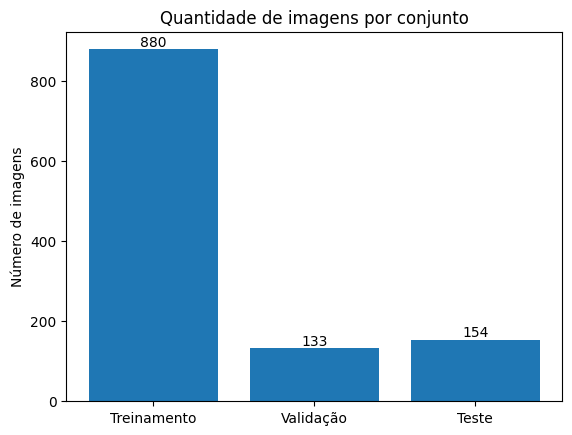

In [141]:
# Gráfico
conjuntos = ["Treinamento", "Validação", "Teste"]
quantidades = [train, validation, test]

ax = plt.bar(conjuntos, quantidades)

plt.title("Quantidade de imagens por conjunto")
plt.ylabel("Número de imagens")

for barra in ax:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        str(int(altura)),
        ha='center',
        va='bottom'
    )

plt.show()

### Integridade dos Arquivos

In [142]:
from PIL import Image
count_corrupted = 0
corrupted = list()

In [143]:
dataframe_list = list()
# 'count_corrupted' and 'corrupted' are initialized in a previous cell

for dataset_folder_name in os.listdir(root_dir):
  dataset_folder_path = os.path.join(root_dir, dataset_folder_name)

  # Ensure it's a directory (e.g., 'train', 'test', 'val') and not a file like 'val.csv' or 'classname.txt'
  if os.path.isdir(dataset_folder_path):
    for class_name_folder in os.listdir(dataset_folder_path):
      class_folder_path = os.path.join(dataset_folder_path, class_name_folder)

      # Ensure it's a directory (e.g., 'healthy', 'angular_leaf_spot', 'bean_rust')
      if os.path.isdir(class_folder_path):
        for image_filename in os.listdir(class_folder_path):
          img_path = os.path.join(class_folder_path, image_filename)

          # Ensure it's an actual file and has a dot for extension splitting
          if os.path.isfile(img_path) and '.' in image_filename:
            _, image_format = image_filename.rsplit('.', 1)
            image_format = image_format.lower()
            img = cv2.imread(img_path)

            if img is not None:
              img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
              # Converter a imagem OpenCV para uma imagem do Pillow
              img_pil = Image.fromarray(img_rgb)

              # Gerar o hash da imagem (usando perceptual hash como exemplo)
              img_hash = imagehash.phash(img_pil)
              width, height, channels = img.shape
              img_corrupted = False
            else:
              count_corrupted += 1
              corrupted.append(img_path)
              img_corrupted = True
              img_hash, image_format, width, height, channels = None, None, None, None, None

            # The 'class_name_folder' is the label for the image
            dataframe_list.append([img_path, img_corrupted, img_hash, image_format, width, height, channels, class_name_folder])

In [144]:
print(f"Total de imagens corrompidas: {count_corrupted}")

if count_corrupted > 0:
    print("\nLista de imagens corrompidas:")
    for img in corrupted:
        print(img)
else:
    print("Nenhuma imagem corrompida foi encontrada.")

Total de imagens corrompidas: 0
Nenhuma imagem corrompida foi encontrada.


In [145]:
print(corrupted)
print(len(corrupted))

[]
0


In [146]:
if corrupted:
    if os.path.exists(corrupted[0]):
        os.remove(corrupted[0])
    else:
        print(f"O arquivo {corrupted[0]} não foi encontrado. Pode já ter sido removido ou não existe.")
else:
    print("Nenhum arquivo corrompido para remover.")

Nenhum arquivo corrompido para remover.


In [147]:
if corrupted:
    print(os.path.exists(corrupted[0]))
else:
    print("Nenhum arquivo corrompido na lista para verificar existência.")

Nenhum arquivo corrompido na lista para verificar existência.


In [148]:
df = pd.DataFrame(columns=['image_path', 'corrupted', 'image_hash', 'image_format', 'width', 'height', 'channels', 'label'], data = dataframe_list)

In [149]:
df.head()

,image_path,corrupted,image_hash,image_format,width,height,channels,label
0,./bean-leaf-lesions-classification/train/angul...,False,a17134e3a2dbd0b9,jpg,500,500,3,angular_leaf_spot
1,./bean-leaf-lesions-classification/train/angul...,False,866c69c39cb3e263,jpg,500,500,3,angular_leaf_spot
2,./bean-leaf-lesions-classification/train/angul...,False,9be924c62b986f31,jpg,500,500,3,angular_leaf_spot
3,./bean-leaf-lesions-classification/train/angul...,False,c6197fe330c33949,jpg,500,500,3,angular_leaf_spot
4,./bean-leaf-lesions-classification/train/angul...,False,8c31ce38eef13ec0,jpg,500,500,3,angular_leaf_spot


#### Verificar se todas as imagens estão no mesmo formato

In [150]:
import os
from collections import Counter

root = "./bean-leaf-lesions-classification"

formatos = []

# Percorre todas as pastas do dataset
for conjunto in ["train", "val", "test"]:
    pasta_conjunto = os.path.join(root, conjunto)

    for classe in os.listdir(pasta_conjunto):
        pasta_classe = os.path.join(pasta_conjunto, classe)

        if not os.path.isdir(pasta_classe):
            continue

        for arquivo in os.listdir(pasta_classe):
            extensao = os.path.splitext(arquivo)[1].lower()
            formatos.append(extensao)

# Conta quantos arquivos existem de cada formato
contagem = Counter(formatos)

print("Formatos encontrados:")
for formato, quantidade in contagem.items():
    print(f"{formato}: {quantidade} imagens")

Formatos encontrados:
.jpg: 1167 imagens


In [151]:
# Tipos de imagens
pastas = {
    "Treinamento": "./bean-leaf-lesions-classification/train",
    "Validação": "./bean-leaf-lesions-classification/val",
    "Teste": "./bean-leaf-lesions-classification/test"
}

for nome_pasta, diretorio in pastas.items():

    formatos = {}

    for classe in os.listdir(diretorio):
        pasta_classe = os.path.join(diretorio, classe)

        if os.path.isdir(pasta_classe):
            for arquivo in os.listdir(pasta_classe):
                extensao = os.path.splitext(arquivo)[1].lower()

                if extensao in formatos:
                    formatos[extensao] += 1
                else:
                    formatos[extensao] = 1

    print(f"\n=== {nome_pasta} ===")
    for formato, quantidade in formatos.items():
        print(f"{formato}: {quantidade} imagens")


=== Treinamento ===
.jpg: 880 imagens

=== Validação ===
.jpg: 133 imagens

=== Teste ===
.jpg: 154 imagens


##### Resumo:


Foi encontrado o arquivo 'healthy_train.120tore' como corrompido e foi excluído.

Foi avaliada a estrutura do dataset

Foi realizada a separação de 15% das imagens de treinamento para teste.

Portanto ficaram 880 imagens para treinamento, 133 imagens de validação e 154 imagens para teste.

Gerado o gráfico.

Verificado se todas as imagens estão no mesmo formato


### Consistência dos Metadados

In [152]:
#Informações estatísticas dos valores de altura, largura e canais das imagens

df.describe().loc[['mean', 'std', 'min', 'max']]

,width,height,channels
mean,500.0,500.0,3.0
std,0.0,0.0,0.0
min,500.0,500.0,3.0
max,500.0,500.0,3.0


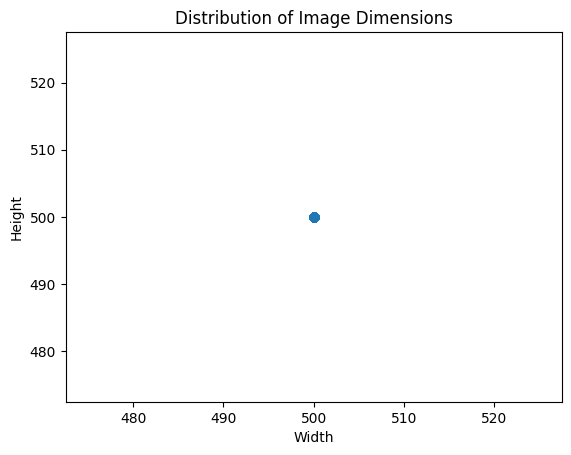

In [153]:
#Distribuição das Dimensões de Altura e Largura das Imagens

plt.scatter(df['width'], df['height'])
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Distribution of Image Dimensions')
plt.show()

In [154]:
print(df.columns)

Index(['image_path', 'corrupted', 'image_hash', 'image_format', 'width',
       'height', 'channels', 'label'],
      dtype='object')


In [155]:
#Quantidade de informações nulas
df.isnull().sum()

,0
image_path,0
corrupted,0
image_hash,0
image_format,0
width,0
height,0
channels,0
label,0


### Qualidade das Imagens

In [156]:
#Total de imagens corrompidas

df['corrupted'].sum()

np.int64(0)

In [157]:
#Quantidade de imagens corrompidas e não corrompidas

df['corrupted'].value_counts()

,count
corrupted,
False,1167


### Distribuição das Classes

### Duplicatas

### Informações complementares
Elaborar uma apresentação para mostrar os resultados.

Apresentar o dataset de forma detalhada.

Verifique quais itens em Informações esperadas podem ser aplicados no dataset.

### ATIVIDADE-04-ETAPA-02

#### Objetivo: Apresentar métodos da literatura e propor ideias para métodos próprios.



### Métodos da literatura

### Métodos próprios

#### Apresentar ideias que podem melhorar os métodos encontrados e testados da literatura.

#### Ideias para melhorar uma técnica

Otimização de Hiperparâmetros - alterar ou reduzir os hiperparâmetros.

Elaborar uma nova arquitetura mais leve para que o treino e o teste sejam rápidos.

Reduzir número de imagens no treinamento e manter o desempenho.

### Informações complementares

Elaborar uma apresentação para mostrar os métodos da literatura e próprios.

### ATIVIDADE-04-ETAPA-03

#### Objetivo

Apresentar métodos da literatura e métodos próprios.

### Metodologia

### Resultados

### Conclusões